# **Beer sound analysis**

This code analyzes the sound measurements made by beer (in our case, mostly non-alcoholic) poured into a glass.

Our research aims to analyze whether density affects the pitch of the sound in a similar way to volume.

## Imports and code setup

Note that the "functions" import (from functions.py) uses also PyAV, Numpy, Glob, Scipy and Pandas. You may need to install them before the first run

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

from IPython.display import display
from beerhemian import load_all, dominant_frequencies, plot_spectrum_multiple, plot_with_curve

from open_atmos_jupyter_utils import show_plot

In [2]:
available_fonts = [f.name for f in fm.fontManager.ttflist]

if "Trebuchet MS" in available_fonts:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Trebuchet MS']

## Density, volume, mass and uncertainties

In [4]:
density = {'Zywiec':        [1.0182, 0.0204],
           'Kasztelan':     [0.9916, 0.0198],
           'Mamrot':        [0.9923, 0.0198],
           'Okocim-wisnia': [0.9758, 0.0195]
           }

In [5]:
volume = {'20':[20.0, 1.0],
          '30':[30.0, 2.0],
          '40':[40.0, 3.0],
          '50':[50.0, 4.0],
          '60':[60.0, 5.0],
          '70':[70.0, 6.0],
          '80':[80.0, 7.0],
          '90':[90.0, 8.0]}

In [6]:
V = np.array([v[0] for v in volume.values()])   # volumes
uV = np.array([v[1] for v in volume.values()])
mass = {}

for name, (rho, d_rho) in density.items():
    m = rho * V
    dm = np.sqrt((V * d_rho)**2 + (rho * uV)**2)
    mass[name] = np.array([m, dm])

In [7]:
for name, arr in mass.items():
    print(f"\n{name}:")
    for vol_key, m, dm in zip(volume.keys(), arr[0], arr[1]):
        print(f"  V={vol_key} ml → mass = {m:.4f} ± {dm:.4f} g")


Zywiec:
  V=20 ml → mass = 20.3640 ± 1.0969 g
  V=30 ml → mass = 30.5460 ± 2.1264 g
  V=40 ml → mass = 40.7280 ± 3.1617 g
  V=50 ml → mass = 50.9100 ± 4.1986 g
  V=60 ml → mass = 61.0920 ± 5.2361 g
  V=70 ml → mass = 71.2740 ± 6.2739 g
  V=80 ml → mass = 81.4560 ± 7.3119 g
  V=90 ml → mass = 91.6380 ± 8.3500 g

Kasztelan:
  V=20 ml → mass = 19.8320 ± 1.0677 g
  V=30 ml → mass = 29.7480 ± 2.0702 g
  V=40 ml → mass = 39.6640 ± 3.0784 g
  V=50 ml → mass = 49.5800 ± 4.0881 g
  V=60 ml → mass = 59.4960 ± 5.0983 g
  V=70 ml → mass = 69.4120 ± 6.1089 g
  V=80 ml → mass = 79.3280 ± 7.1196 g
  V=90 ml → mass = 89.2440 ± 8.1305 g

Mamrot:
  V=20 ml → mass = 19.8460 ± 1.0684 g
  V=30 ml → mass = 29.7690 ± 2.0716 g
  V=40 ml → mass = 39.6920 ± 3.0805 g
  V=50 ml → mass = 49.6150 ± 4.0908 g
  V=60 ml → mass = 59.5380 ± 5.1017 g
  V=70 ml → mass = 69.4610 ± 6.1130 g
  V=80 ml → mass = 79.3840 ± 7.1244 g
  V=90 ml → mass = 89.3070 ± 8.1360 g

Okocim-wisnia:
  V=20 ml → mass = 19.5160 ± 1.0508 g
  V=

## Live analysis using Friture

Apart from recording audio we analyzed live the frequencies using Friture

In [8]:
friture_zywiec = \
    {'frequencies': [1304, 1301, 1295, 1289, 1277, 1257, 1233, 1195],
    'mass': mass['Zywiec'][0],
     'mass_uncertainty': mass['Zywiec'][1]}
friture_kasztelan = \
    {'frequencies': [1298, 1295, 1289, 1280, 1269, 1251, 1225, 1189],
    'mass': mass['Kasztelan'][0],
     'mass_uncertainty': mass['Kasztelan'][1]}
friture_mamrot = \
    {'frequencies': [1301, 1301, 1298, 1289, 1277, 1257, 1233, 1201],
    'mass': mass['Mamrot'][0],
     'mass_uncertainty': mass['Mamrot'][1]}
friture_okocim = \
    {'frequencies': [1301, 1295, 1289, 1283, 1266, 1248, 1225, 1184],
    'mass': mass['Okocim-wisnia'][0],
     'mass_uncertainty': mass['Okocim-wisnia'][1]}

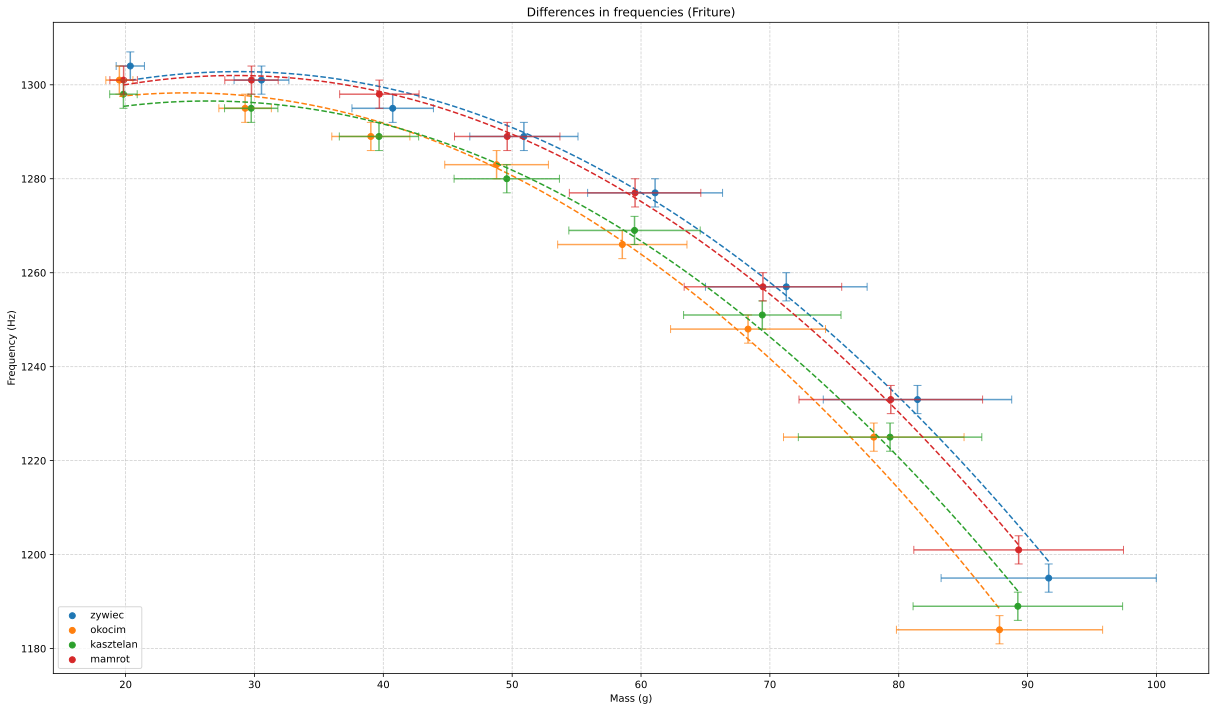

In [9]:
plt.figure(figsize=(17, 10))

plot_with_curve('zywiec', friture_zywiec['mass'], friture_zywiec['mass_uncertainty'], friture_zywiec['frequencies'])
plot_with_curve('okocim', friture_okocim['mass'], friture_okocim['mass_uncertainty'], friture_okocim['frequencies'])
plot_with_curve('kasztelan', friture_kasztelan['mass'], friture_kasztelan['mass_uncertainty'], friture_kasztelan['frequencies'])
plot_with_curve('mamrot', friture_mamrot['mass'], friture_mamrot['mass_uncertainty'], friture_mamrot['frequencies'])


plt.title('Differences in frequencies (Friture)', loc='center')
plt.xlabel("Mass (g)", loc='center')
plt.ylabel("Frequency (Hz)", loc='center')

plt.legend(loc='lower left', prop={'size': 10})
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
show_plot()

## Reading sound files

### Analysis of the .wav files

In [10]:
DIR = os.path.join(os.getcwd(), "DIR")
beer_folders_dir = [d for d in os.listdir(DIR) if os.path.isdir(os.path.join(DIR, d))]

print(f"Found beer's folders: {beer_folders_dir}\n" + "-"*40)

Found beer's folders: ['Okocim-wisnia', 'Kasztelan', 'Zywiec', 'Mamrot']
----------------------------------------


Loaded: okocim-wisnia-20_cut.wav | 44100 Hz | 1.49s
Loaded: okocim-wisnia-30_cut.wav | 44100 Hz | 1.24s
Loaded: okocim-wisnia-40_cut.wav | 384000 Hz | 1.77s
Loaded: okocim-wisnia-50_cut.wav | 384000 Hz | 2.27s
Loaded: okocim-wisnia-60_cut.wav | 44100 Hz | 1.89s
Loaded: okocim-wisnia-70_cut.wav | 44100 Hz | 1.89s
Loaded: okocim-wisnia-80_cut.wav | 44100 Hz | 1.54s
Loaded: okocim-wisnia-90_cut.wav | 44100 Hz | 1.20s
Loaded: kasztelan-20_cut.wav | 384000 Hz | 1.10s
Loaded: kasztelan-30_cut.wav | 384000 Hz | 1.05s
Loaded: kasztelan-40_cut.wav | 384000 Hz | 1.02s
Loaded: kasztelan-50_cut.wav | 384000 Hz | 0.96s
Loaded: kasztelan-60_cut.wav | 384000 Hz | 1.00s
Loaded: kasztelan-70_cut.wav | 384000 Hz | 0.99s
Loaded: kasztelan-80_cut.wav | 384000 Hz | 0.96s
Loaded: kasztelan-90_cut.wav | 384000 Hz | 1.27s
Loaded: zywiec-20_cut.wav | 384000 Hz | 1.47s
Loaded: zywiec-30_cut.wav | 384000 Hz | 1.08s
Loaded: zywiec-40_cut.wav | 384000 Hz | 1.33s
Loaded: zywiec-50_cut.wav | 384000 Hz | 1.44s
Loaded

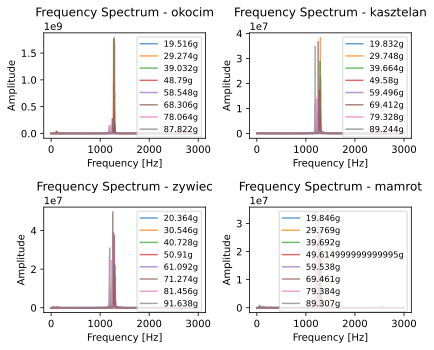

In [11]:
n_beers = len(beer_folders_dir)
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes = axes.flatten()

all_results_wav = []

for ax, beer in zip(axes, beer_folders_dir):
    folder_path = os.path.join(DIR, beer)
    recordings = load_all(folder_path)

    if not recordings:
        ax.set_visible(False)
        continue

    beer_res, fft_data = dominant_frequencies(
        recordings,
        mass=mass[beer][0],
        mass_unc=mass[beer][1]
    )
    all_results_wav.append(beer_res)
    plot_spectrum_multiple(fft_data, beer_res, ax=ax)

plt.tight_layout()
plt.show()

### Analysis of the .m4a files

In [12]:
NOTEBOOK_DIR = os.path.join(os.getcwd(), "NOTEBOOK_DIR")
beer_folders = [d for d in os.listdir(NOTEBOOK_DIR) if os.path.isdir(os.path.join(NOTEBOOK_DIR, d))]

print(f"Found beer's folders: {beer_folders}\n" + "-"*40)

Found beer's folders: ['Okocim-wisnia', 'Kasztelan', 'Zywiec', 'Mamrot']
----------------------------------------


Loaded: okocim-wisnia-20.m4a | 48000 Hz | 10.43s
Loaded: okocim-wisnia-30.m4a | 48000 Hz | 12.99s
Loaded: okocim-wisnia-40.m4a | 48000 Hz | 11.03s
Loaded: okocim-wisnia-50.m4a | 48000 Hz | 13.25s
Loaded: okocim-wisnia-60.m4a | 48000 Hz | 13.50s
Loaded: okocim-wisnia-70.m4a | 48000 Hz | 10.52s
Loaded: okocim-wisnia-80.m4a | 48000 Hz | 12.05s
Loaded: okocim-wisnia-90.m4a | 48000 Hz | 14.36s
Loaded: kasztelan-20.m4a | 48000 Hz | 10.09s
Loaded: kasztelan-30.m4a | 48000 Hz | 10.60s
Loaded: kasztelan-40.m4a | 48000 Hz | 11.45s
Loaded: kasztelan-50.m4a | 48000 Hz | 10.43s
Loaded: kasztelan-60.m4a | 48000 Hz | 10.86s
Loaded: kasztelan-70.m4a | 48000 Hz | 12.65s
Loaded: kasztelan-80.m4a | 48000 Hz | 10.17s
Loaded: kasztelan-90.m4a | 48000 Hz | 10.60s
Loaded: zywiec-20.m4a | 48000 Hz | 10.94s
Loaded: zywiec-30.m4a | 48000 Hz | 12.73s
Loaded: zywiec-40.m4a | 48000 Hz | 10.52s
Loaded: zywiec-50.m4a | 48000 Hz | 12.39s
Loaded: zywiec-60.m4a | 48000 Hz | 10.35s
Loaded: zywiec-70.m4a | 48000 Hz | 10.

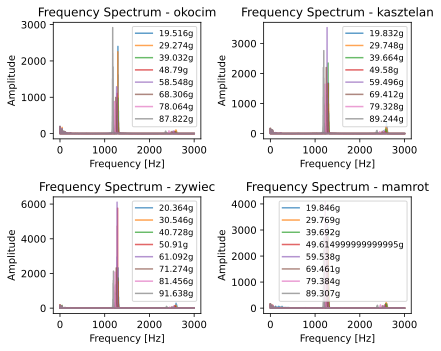

In [13]:
n_beers = len(beer_folders_dir)
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes = axes.flatten()

all_results_m4a = []

for ax, beer in zip(axes, beer_folders_dir):
    folder_path = os.path.join(NOTEBOOK_DIR, beer)
    recordings = load_all(folder_path)

    if not recordings:
        ax.set_visible(False)
        continue

    beer_res, fft_data = dominant_frequencies(
        recordings,
        mass=mass[beer][0],
        mass_unc=mass[beer][1]
    )
    all_results_m4a.append(beer_res)
    plot_spectrum_multiple(fft_data, beer_res, ax=ax)

plt.tight_layout()
plt.show()

#### Results

Plot of combined results

for .wav

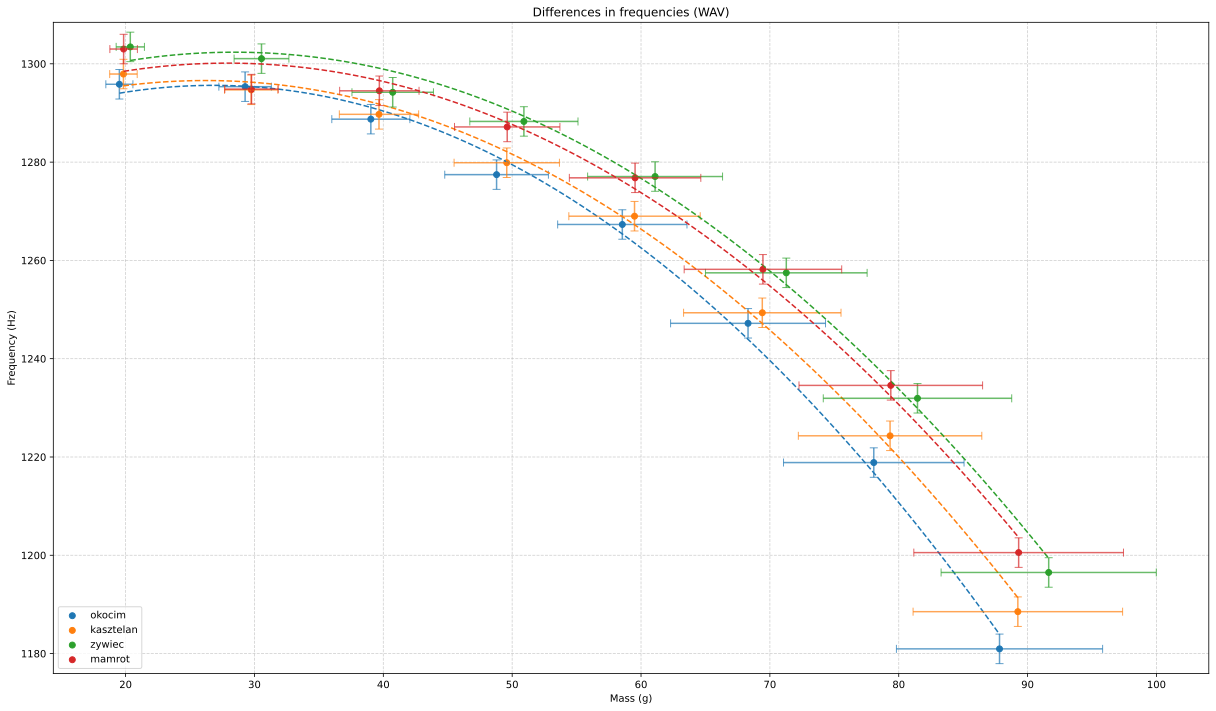

In [14]:
plt.figure(figsize=(17, 10))

for df in all_results_wav:
    beer_name = df['Beer'].iloc[0]
    mass = df['mass']
    frequencies = df['frequencies']
    um = df['um']
    plot_with_curve(beer_name, mass, um, frequencies)



plt.title('Differences in frequencies (WAV)', loc='center')
plt.xlabel("Mass (g)", loc='center')
plt.ylabel("Frequency (Hz)", loc='center')

f_min = [df['frequencies'].min() for df in all_results_wav]
f_max = [df['frequencies'].max() for df in all_results_wav]

plt.ylim(min(f_min)-5, max(f_max)+5) 
plt.legend(loc='lower left', prop={'size': 10}) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
show_plot()

for .m4a

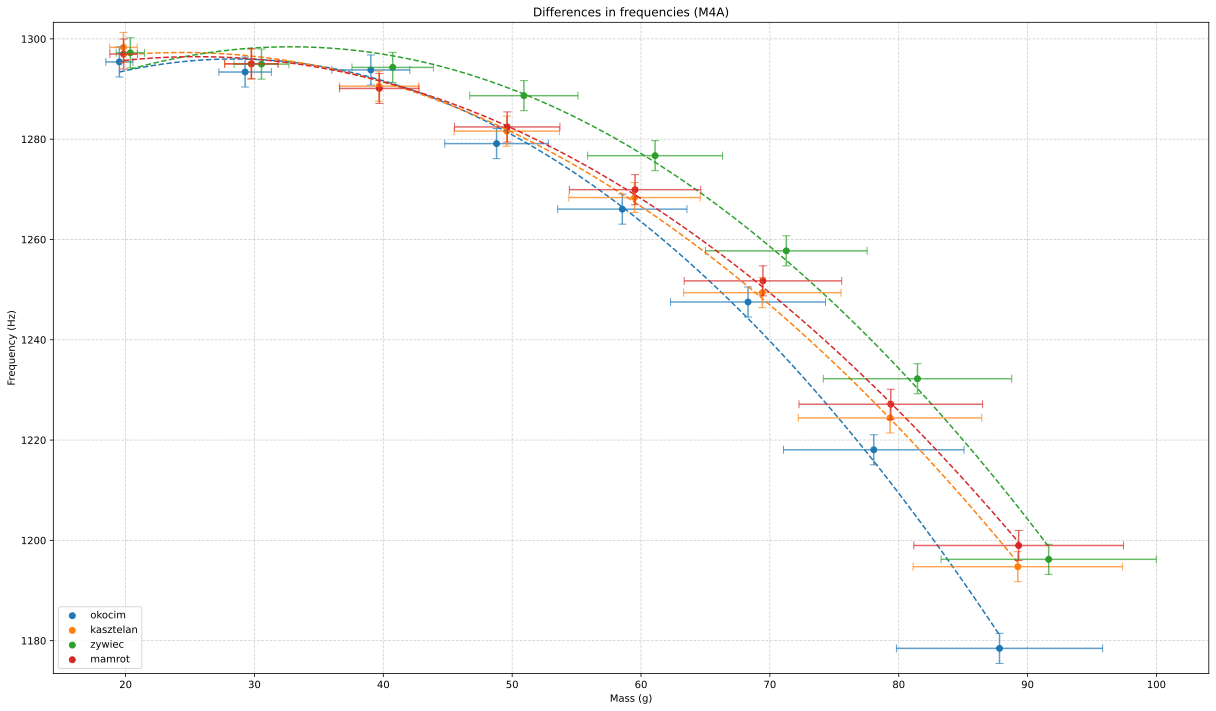

In [15]:
plt.figure(figsize=(17, 10))

for df in all_results_m4a:
    beer_name = df['Beer'].iloc[0]
    mass = df['mass']
    frequencies = df['frequencies']
    um = df['um']
    plot_with_curve(beer_name, mass, um, frequencies)


plt.title('Differences in frequencies (M4A)', loc='center')
plt.xlabel("Mass (g)", loc='center')
plt.ylabel("Frequency (Hz)", loc='center')

f_min = [df['frequencies'].min() for df in all_results_m4a]
f_max = [df['frequencies'].max() for df in all_results_m4a]

plt.ylim(min(f_min)-5, max(f_max)+5) 
plt.legend(loc='lower left', prop={'size': 10}) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
show_plot()